# Bayes Rules
## Chapter 6. Approximating the Posterior

Code adapted from: https://github.com/pymc-devs/pymc-resources/tree/main/Bayes_Rules

Antonio Esteves @ UMinho

![](BayesRules-book-cover.png)

In [1]:
import aesara   as at
import arviz    as az
import numpy    as np
import pandas   as pd
import pymc     as pm
import pyreadr
import requests
import seaborn           as sns
import matplotlib.pyplot as plt

from   plotnine    import aes, geom_point, geom_segment, ggplot, stat_function, geom_histogram, lims
from   scipy.stats import beta, binom, gamma, poisson

In [2]:
%config InlineBackend.figure_format = 'retina'
%load_ext watermark
%load_ext nb_black

RANDOM_SEED = 1301

np.random.seed(RANDOM_SEED)
az.style.use("arviz-darkgrid")

<IPython.core.display.Javascript object>

In [3]:
pm.__version__

'5.10.3'

<IPython.core.display.Javascript object>

In [4]:
at.__version__

'2.9.3'

<IPython.core.display.Javascript object>

## 6.1 Grid approximation

## 6.1.1 A Beta-Binomial example

Let us explore a Beta-Binomial model with $Y|\pi \sim Binom(10,\pi)$ and $\pi \sim Beta(2,2)$.<P>
We can interpret $Y$ as the number of successes in 10 independent trials, where each trial has a probability of success equal to $\pi$. Our prior understanding about parameter $\pi$ is captured by a $Beta(2,2)$ model. Suppose we observe $Y=9$ successes.<P>

The updated posterior model of $\pi$ follows a Beta distribution with parameters $Y + \alpha = 9 + 2 = 11$ and $n - Y + \beta = 10 − 9 + 2 = 3$: $p(\pi|Y=9) \sim Beta(11,3)$.<P>

We are now going to forget that we were able to specify this posterior. Instead, we will try to approximate it using grid approximation.<P>

In Step 1, we will split the continuum of possible $\pi$ values, in range 0 to 1, into a finite grid. We will start with a grid of only 6 $\pi$ values: $\pi \in \{0, 0.2, 0.4, 0.6, 0.8, 1\}$.


In [5]:
# Create a grid of values for pi

grid_data = pd.DataFrame(data={"pi_grid": np.linspace(0, 1, 6)})
grid_data

,pi_grid
0,0.0
1,0.2
2,0.4
3,0.6
4,0.8
5,1.0


<IPython.core.display.Javascript object>

In step 2, we create two new DataFrame columns por prior and likelihood: 
* prior $p(\pi) = Beta(2,2)$
* likelihood $p(Y \mid \pi) = Binom(9, 10, \pi)$
The prior and lilelihood as calculated for the grid points of $\pi$.

In [6]:
grid_data = grid_data.assign(
    prior      = beta.pdf(grid_data["pi_grid"], 2, 2),
    likelihood = binom.pmf(9, 10, grid_data["pi_grid"]),
)

<IPython.core.display.Javascript object>

In [7]:
grid_data

,pi_grid,prior,likelihood
0,0.0,0.00,0.000000
1,0.2,0.96,0.000004
2,0.4,1.44,0.001573
3,0.6,1.44,0.040311
4,0.8,0.96,0.268435
5,1.0,0.00,0.000000


<IPython.core.display.Javascript object>

In Step 3, we calculate the product of the likelihood and prior at each grid value. This is the numerator of Bayes rule, and provides an unnormalized discrete approximation of the posterior PDF that does not sum to 1. We subsequently normalize this approximation by dividing each unnormalized posterior value by their collective sum, i.e., the marginal probability p(data).

$p(\pi \mid data) = \frac{p(data \mid \pi) * p(\pi)}{\sum_{all\ \pi} p(data \mid \pi) * p(\pi)}$

In [8]:
# Compute the prior * likelihood

grid_data = grid_data.assign(
    unnormalised = grid_data["likelihood"] * grid_data["prior"],
)

<IPython.core.display.Javascript object>

In [9]:
# Compute the posterior = (prior * likelihood)/ p(data)
# p(data) = SUM_all_pi (prior * likelihood), since we deal with discretized probabilities-

grid_data = grid_data.assign(
    posterior=grid_data["unnormalised"] / grid_data["unnormalised"].sum()
)

<IPython.core.display.Javascript object>

The resulting discretized posterior PDF, rounded to 2 decimal places is
plotted below. It provides a very rigid a simplified overfied of the actual posterior. This approximation gives a 99% probability that $\pi$ is either 0.6 or 0.8, 1% chance that $\pi$ is
0.4, and a near 0% chance that $\pi$ assumes other value.

In [10]:
grid_data

,pi_grid,prior,likelihood,unnormalised,posterior
0,0.0,0.00,0.000000,0.000000,0.000000
1,0.2,0.96,0.000004,0.000004,0.000012
2,0.4,1.44,0.001573,0.002265,0.007122
3,0.6,1.44,0.040311,0.058048,0.182531
4,0.8,0.96,0.268435,0.257698,0.810334
5,1.0,0.00,0.000000,0.000000,0.000000


<IPython.core.display.Javascript object>

In [11]:
grid_data.sum()

pi_grid         3.000000
prior           4.800000
likelihood      0.310323
unnormalised    0.318014
posterior       1.000000
dtype: float64

<IPython.core.display.Javascript object>

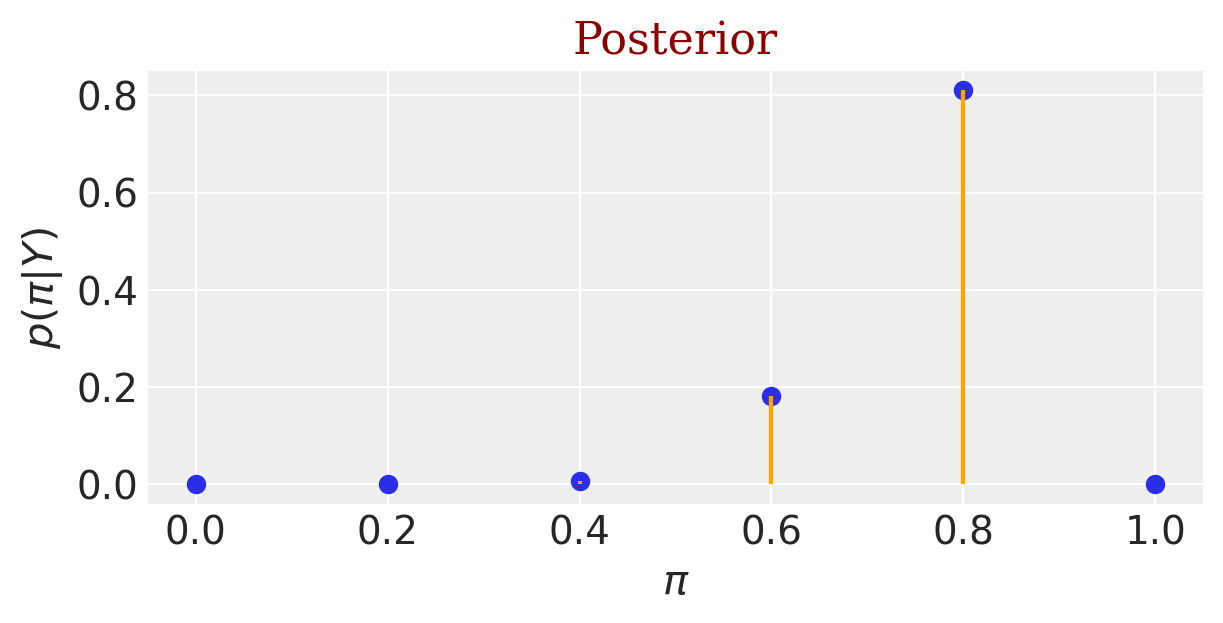

<IPython.core.display.Javascript object>

In [12]:
font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 16,
        }

fig = plt.figure(figsize=(6,3))

plt.plot(grid_data["pi_grid"], grid_data["posterior"], "o")
plt.vlines(x=grid_data["pi_grid"], ymin=0, ymax=grid_data["posterior"],
           colors = 'orange',label = 'vlines')
plt.title('Posterior', fontdict=font)
plt.xlabel(r'$\pi$')
plt.ylabel(r'$p(\pi|Y)$')
plt.show()

You might anticipate what happend when we use this approximation to simulate samples from the posterior in Step 4. Each sample we draw has only 6 possible outcomes and is highly likely to be 0.6 or 0.8.

Let us use `sample_n()` to take a sample of size 10000 from the discretized posterior, with replacement, and using the discretized posterior probabilities as sample weights.

In [13]:
# get a random sample of 10000 values from the column 'posterior', with replacement,
# and using posterior probabilities as weights to conditioning the sampling frequency 
# of each outcome.

sample = grid_data.sample(10000, weights=grid_data["posterior"], replace=True)

<IPython.core.display.Javascript object>

In [14]:
sample

,pi_grid,prior,likelihood,unnormalised,posterior
4,0.8,0.96,0.268435,0.257698,0.810334
4,0.8,0.96,0.268435,0.257698,0.810334
4,0.8,0.96,0.268435,0.257698,0.810334
4,0.8,0.96,0.268435,0.257698,0.810334
4,0.8,0.96,0.268435,0.257698,0.810334
...,...,...,...,...,...
4,0.8,0.96,0.268435,0.257698,0.810334
4,0.8,0.96,0.268435,0.257698,0.810334
4,0.8,0.96,0.268435,0.257698,0.810334
4,0.8,0.96,0.268435,0.257698,0.810334


<IPython.core.display.Javascript object>

As expected, most of our 10000 sampled values of $\pi$ are 0.8 or 0.68, and a few are 0.4. 
There are no values below 0.4 or above 0.8.

In [15]:
post_sample = pd.concat(
    [
       sample["pi_grid"].value_counts().rename("n"),
       sample["pi_grid"].value_counts(normalize=True).rename("percent"),
    ],
    axis=1
)

<IPython.core.display.Javascript object>

In [16]:
post_sample

,n,percent
pi_grid,,
0.8,8059,0.8059
0.6,1875,0.1875
0.4,66,0.0066


<IPython.core.display.Javascript object>

The posterior probabilities are an extremely oversimplied approximation of the true $Beta(11,
3)$ distribution. Next plot superimposes the true posterior PDF $f(\pi|Y)$ on a scaled histogram of the 10000 sample values. If we are dealing with a good approximation, the histogram would mimic the shape, location, and spread of the smooth pdf. Bu it does not.

In [18]:
y_grid = sample['posterior'].values
print(y_grid)

sample["posterior"].value_counts()

[0.81033443 0.81033443 0.81033443 ... 0.81033443 0.81033443 0.81033443]


posterior
0.810334    8059
0.182531    1875
0.007122      66
Name: count, dtype: int64

<IPython.core.display.Javascript object>

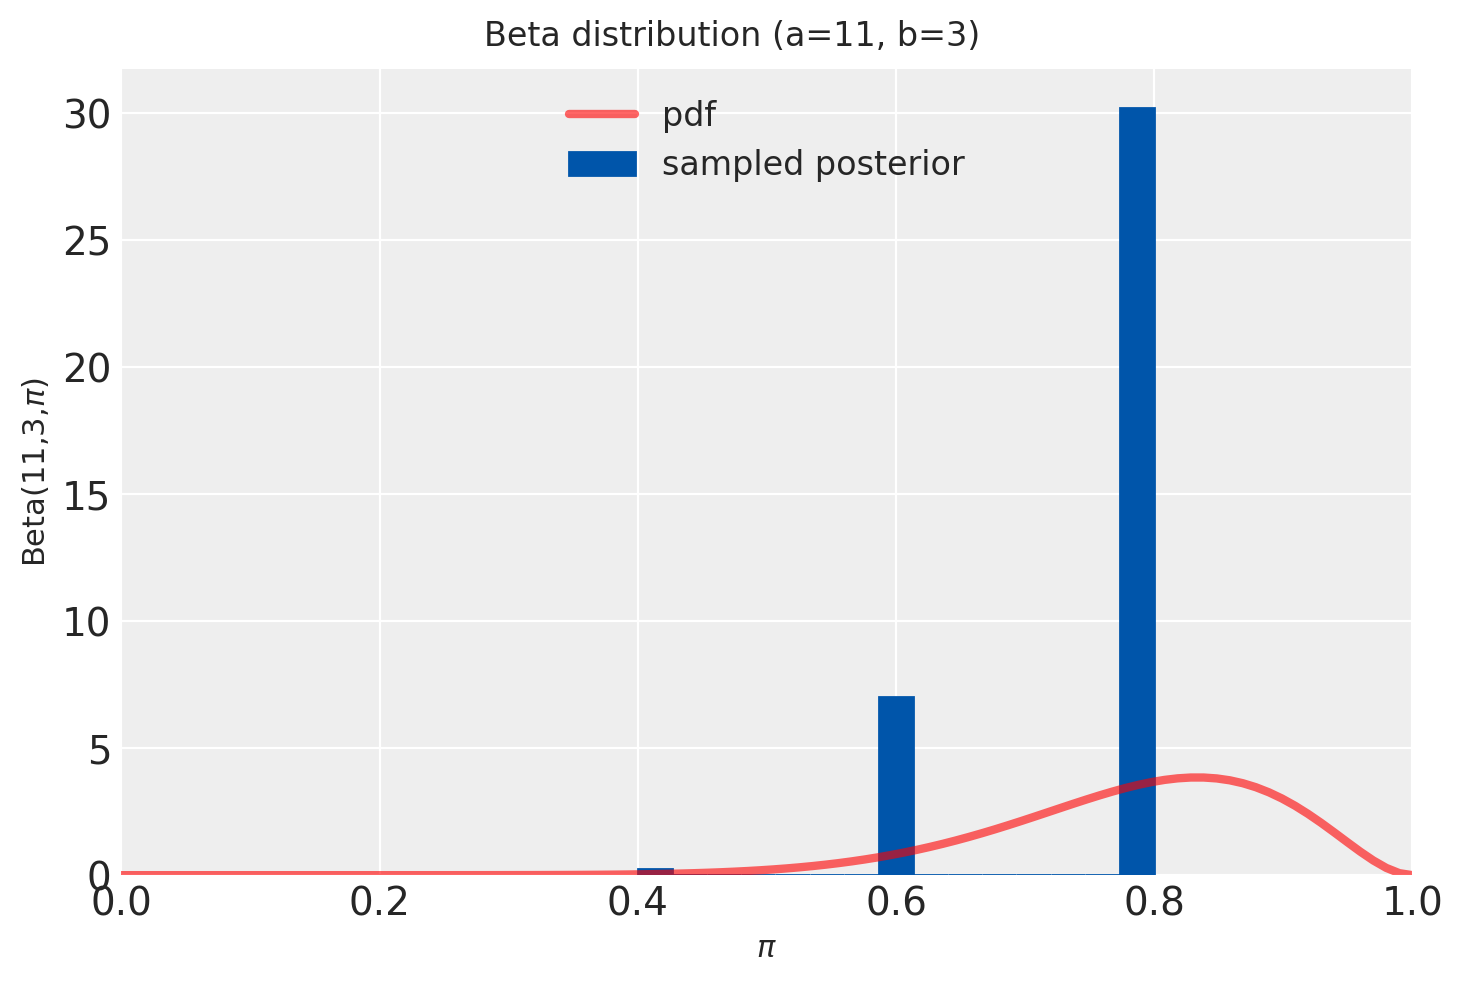

<IPython.core.display.Javascript object>

In [19]:
a = 11  
b = 3

x_hist = grid_data["pi_grid"]
y_hist = sample['pi_grid']
x_pdf  = np.linspace(0, 1, 100)

fig, ax = plt.subplots(1, 1)

# Display the Beta(11,3) PDF

ax.plot(x_pdf, beta.pdf(x_pdf, a=a, b=b), 'r-', lw=3, alpha=0.6, label='pdf')

# Plot the posterior sample histogram

ax.set_xlim(0, 1)
sns.histplot(ax=ax, data=y_hist, stat='density', discrete=False, kde=False,
            facecolor='#0055AA', edgecolor='#0055AA', label='sampled posterior')
ax.set_ylabel(f'Beta({a},{b},$\pi$)', fontsize=11)
ax.set_xlabel(r'$\pi$', fontsize=11)
fig.suptitle(f'Beta distribution (a={a}, b={b})')
plt.legend(loc='upper center', fontsize= 12)

plt.show()

Instead of discretizing the continuous range [0:1] of possible $\pi$ values into a grid of only 6 values, let us try a
more reasonable grid of 101 values: $\pi \in \{0, 0.01, 0.02, ... , 0.99, 1\}$. The first 3 steps of the grid approximation, for this new grid of values, are performed below.

In [20]:
# define a grid of 101 values to discretize the [0:1] range

grid_data2 = pd.DataFrame(data={"pi_grid": np.linspace(0, 1, 101)})

# Calculate the prior and likelihood at these grid point

grid_data2 = grid_data2.assign(
    prior=beta.pdf(grid_data2["pi_grid"], 2, 2),
    likelihood=binom.pmf(9, 10, grid_data2["pi_grid"]),
)

# Calculate the un-normalized posterior = likelihood*prior at these grid point

grid_data2 = grid_data2.assign(
    unnormalised=grid_data2["likelihood"] * grid_data2["prior"]
)

# Approximate the postetior using Bayes at these grid points

grid_data2 = grid_data2.assign(
    posterior=grid_data2["unnormalised"] / grid_data2["unnormalised"].sum()
)

<IPython.core.display.Javascript object>

In [21]:
grid_data2.sum()

pi_grid         50.500000
prior           99.990000
likelihood       9.082579
unnormalised     6.993002
posterior        1.000000
dtype: float64

<IPython.core.display.Javascript object>

The resulting discretized posterior PDF is quite smooth, especially in comparison to the rigid approximation when we only used 6 grid values.

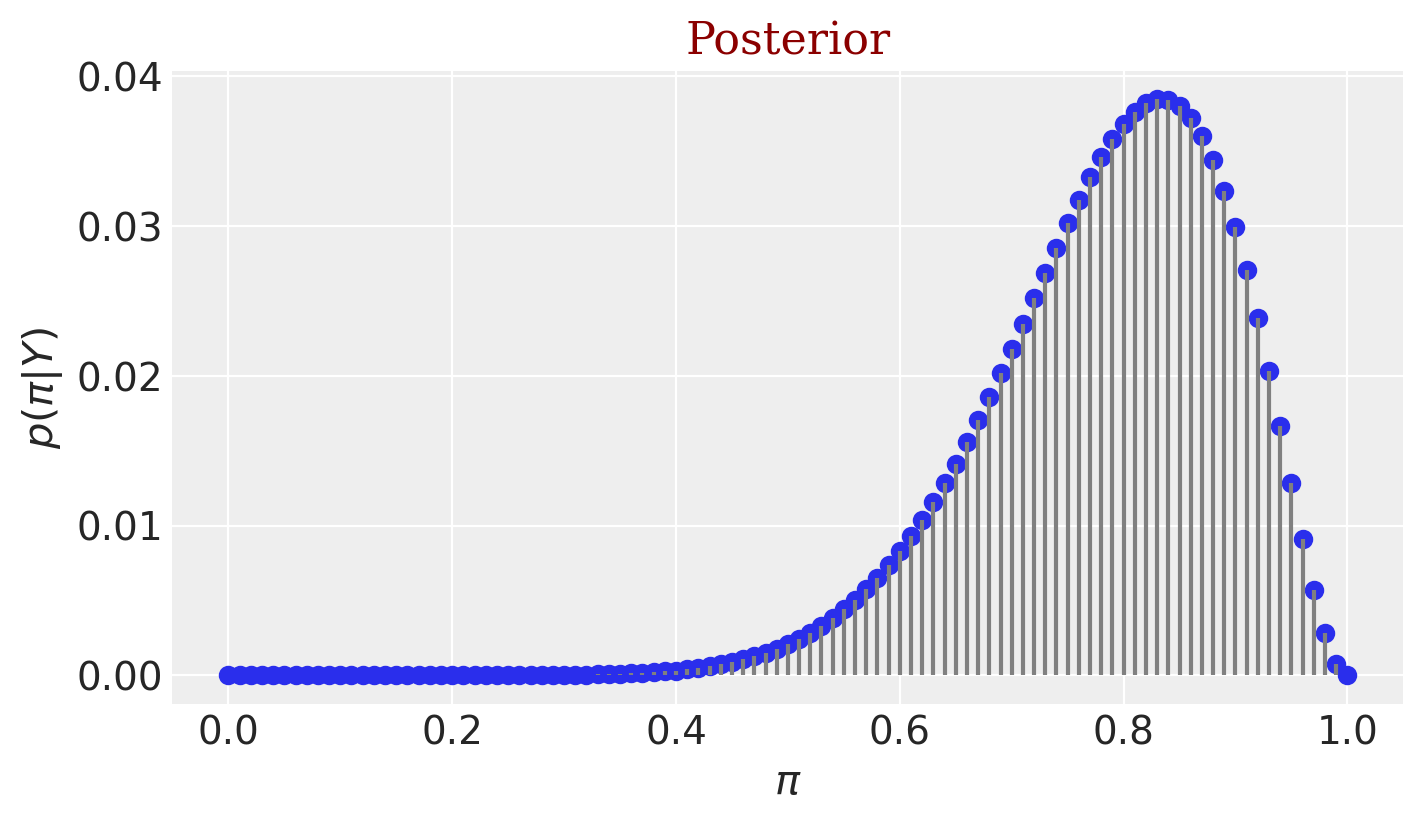

<IPython.core.display.Javascript object>

In [22]:
font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 16,
        }

fig = plt.figure(figsize=(7,4))

plt.plot(grid_data2["pi_grid"], grid_data2["posterior"], "o")
plt.vlines(x=grid_data2["pi_grid"], ymin=0, ymax=grid_data2["posterior"],
           colors = 'gray',label = 'vlines')
plt.title('Posterior', fontdict=font)
plt.xlabel(r'$\pi$')
plt.ylabel(r'$p(\pi|Y)$')
plt.show()

Finally, in step 4 of the grid approximation, we draw 10000 sample from the discretized posterior PDF.

In [23]:
sample2 = grid_data2.sample(10000, weights=grid_data2["posterior"], replace=True)

<IPython.core.display.Javascript object>

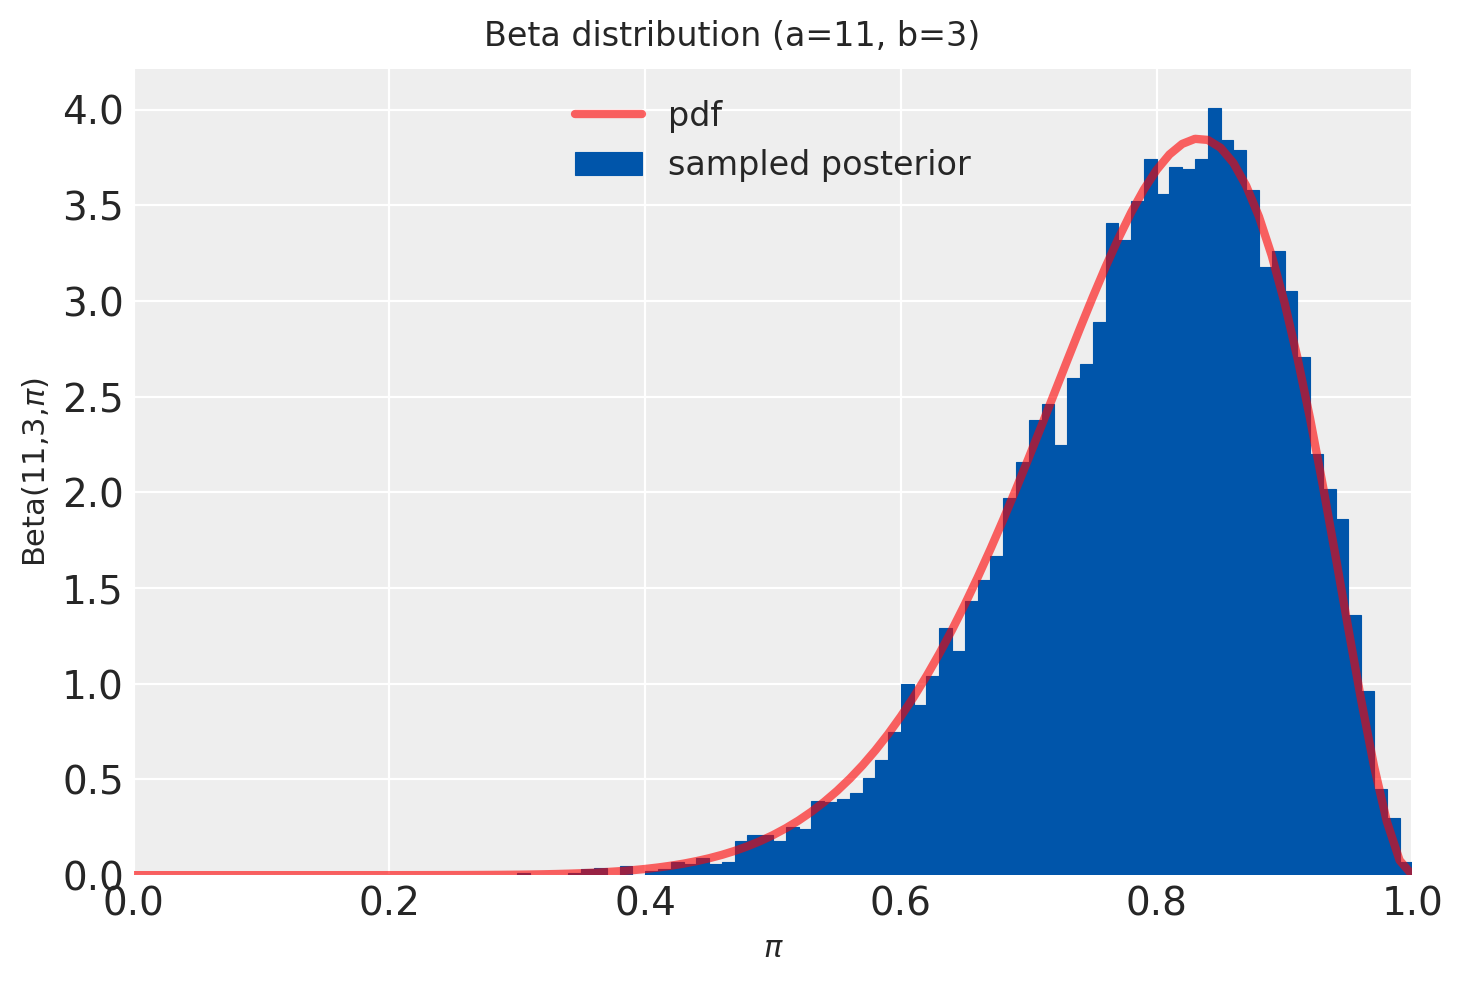

<IPython.core.display.Javascript object>

In [25]:
a = 11  
b = 3

pi_grid = grid_data2["pi_grid"]
y_hist  = sample2['pi_grid']

fig, ax = plt.subplots(1, 1)

# Display the Beta(11,3) PDF

ax.plot(pi_grid, beta.pdf(pi_grid, a=a, b=b), 'r-', lw=3, alpha=0.6, label='pdf')

# Plot the posterior sample histogram

ax.set_xlim(0, 1)
sns.histplot(ax=ax, bins=pi_grid, data=y_hist, stat='density', discrete=False, kde=False,
            facecolor='#0055AA', edgecolor='#0055AA', label='sampled posterior')
ax.set_ylabel(f'Beta({a},{b},$\pi$)', fontsize=11)
ax.set_xlabel(r'$\pi$', fontsize=11)
fig.suptitle(f'Beta distribution (a={a}, b={b})')
plt.legend(loc='upper center', fontsize= 12)

plt.show()

## 6.1.2 A Gamma-Poisson example

Let us apply the grid approximation technique to simulate the posterior of another Bayesian model, this time a Gamma-Poisson. Let $Y$ be the number of events that occur in a one-hour period, where events occur at an average rate of $\lambda$ per hour. Further, suppose we collect two data points $(Y_1,Y_2)$ and use a $Gamma(3,1)$ prior on $\lambda$:<P>

$Y_i \mid \lambda \sim Poisson(\lambda)$ <P>
$\lambda \sim Gamma(3,1)$ <P>

If we observe $Y_1=2$ events in the first one-hour observation period and $Y_2=8$ in the next. The updated posterior model of $\lambda$ is a Gamma distribution with parameters $s + \sum Y\ =\ 3 + 10\ =\ 13$ and $r + n\ =\ 1 + 2\ = \ 3$:<P>

$\lambda \mid ((Y_1,Y_2)=(2,3)) \sim Gamma(13,3)$

To simulate this posterior using grid approximation, Step 1 is to specify a discrete grid of reasonable $\lambda$ values. Unlike the $\pi$ parameter in the Beta-Binomial which is restricted to the [0:1] interval, the Poisson parameter $\lambda$ can technically take on any non-negative real value ($\lambda \in [0, \infty)$). However, in a plot of the Gamma prior PDF and Poisson likelihood function it appears that, though possible, values of $\lambda$ beyond 15 are implausible. With this in mind, we will set up a discrete grid of $\lambda$ values between 0 and 15, essentially truncating the posterior's tail.

Much of this code is the same as it was for the Beta-Binomial model. There are two key differences. First, we use `gamma` and `poisson` instead of `beta` and `binom` to evaluate the prior PDF and likelihood function of $\lambda$. Second, since we have a sample of two data points $(Y_1,Y_2)=(2,8)$, the Poisson likelihood function of $\lambda$ must be calculated by the product of the marginal Poisson PDFs, $L(\lambda \mid y_1,y_2) = f(y_1,y_2 \mid \lambda) = f(y_1 \mid \lambda) f(y_2 \mid \lambda)$.

In [26]:
# 1. Define a discretization grid of 501 points

grid_data3 = pd.DataFrame(data={"lambda_grid": np.linspace(0, 15, 501)})

# 2. Calculate the prior and likelihood at the grid points

grid_data3 = grid_data3.assign(
    prior      = gamma.pdf(grid_data3["lambda_grid"], 3, 1),
    likelihood = poisson.pmf(2, grid_data3["lambda_grid"]) * 
                 poisson.pmf(8, grid_data3["lambda_grid"]),
)

# 3. Calculate the un-normalized posterior at the grid points = likelihood * prior

grid_data3 = grid_data3.assign(
    unnormalised=grid_data3["likelihood"] * grid_data3["prior"],
)

# 4. Approximate the posterior at the grid points

grid_data3 = grid_data3.assign(
    posterior=grid_data3["unnormalised"] / grid_data3["unnormalised"].sum()
)

<IPython.core.display.Javascript object>

In [27]:
# 5. Draw 10000 samples from the posterior, with replacement and using posterior 
#    probabilities as weights to conditioning the sampling frequency of each outcome.

sample3 = grid_data3.sample(10000, weights=grid_data3["posterior"], replace=True)

<IPython.core.display.Javascript object>

The grid approximation again produced a decent approximation of our target posterior.

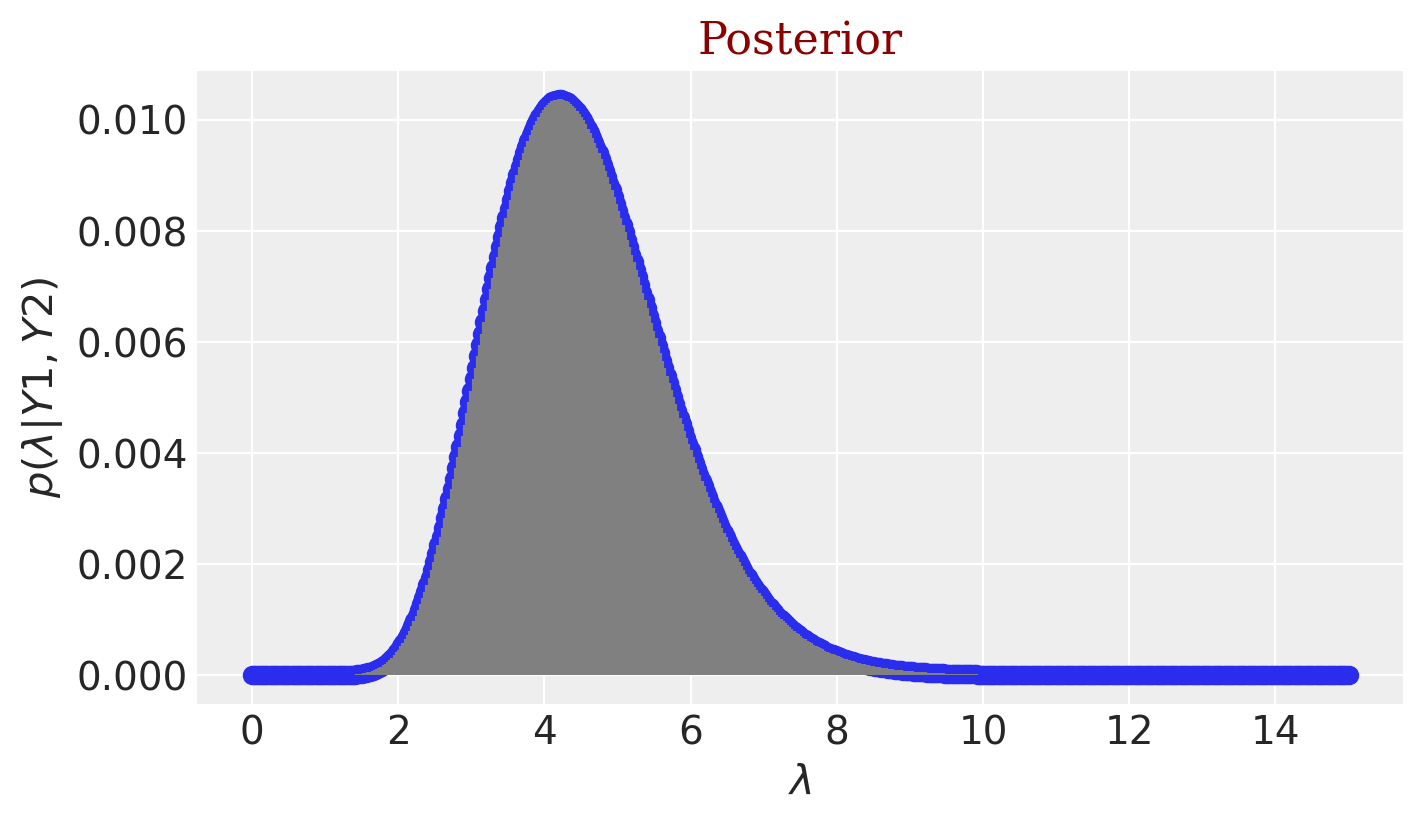

<IPython.core.display.Javascript object>

In [28]:
font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 16,
        }

fig = plt.figure(figsize=(7,4))

plt.plot(grid_data3["lambda_grid"], grid_data3["posterior"], "o")
plt.vlines(x=grid_data3["lambda_grid"], ymin=0, ymax=grid_data3["posterior"],
           colors = 'gray',label = 'vlines')
plt.title('Posterior', fontdict=font)
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$p(\lambda|Y1,Y2)$')
plt.show()

## 6.2 Markov chains via `pymc`  

Like in grid approximation, MCMC samples are not taken directly from the posterior PDF $f(\theta|y)$. Yet unlike grid approximation samples, MCMC samples are not even independent, meaning that each subsequent sample value depends directly upon the previous value. Let {$\theta^{(1)}$, $\theta^{(2)}$,..., $\theta^{(N)}$} be an $N$-length MCMC sample, or Markov chain. In constructing this chain, $\theta^{(2)}$ is drawn from some model that depends upon $\theta^{(1)}$, $\theta^{(3)}$, is drawn from some model that depends upon $\theta^{(2)}$, $\theta^{(4)}$ is drawn from some model that depends upon $\theta^{(3)}$, and so on fo the rest of the chain. In general, the $(i+1)$ chain value, $\theta^{(i+1)}$, is drawn from a model that depends on data $y$ and the previous chain value, $\theta^{(i)}$, with conditional PDF $f\theta^{(i+1)} \mid \theta^{(i)},y)$.

There are a couple of things to note about this dependence among chain values. First, in first order Markov chains, $\theta^{(i+1)}$ depends upon the preceding chain value only $\theta^{(i)}$. This can be expressed through the following equality:

$f(\theta^{(i+1)} \mid \theta^{(1)}, \theta^{(2)}, \dots, \theta^{(i)}, y) = f(\theta^{(i+1)} \mid \theta^{(i)},y)$

For example, since $\theta^{(i+i)}$ depends on $\theta^{(i)}$, which depends on $\theta^{(i−1)}$, it is also
true that $\theta^{(i+i)}$ depends on $\theta^{(i−1)}$. However, if we know $\theta^{(i)}$, then $\theta^{(i−1)}$ is of no consequence to $\theta^{(i+1)}$. The only information we need to simulate $\theta^{(i+1)}$ is the value of $\theta^{(i)}$. Further, each chain value can be drawn from a different model, and none of these models are the target posterior. That is, the PDF from which a Markov chain value is simulated is not equivalent to the posterior PDF: <P>

$f(\theta^{(i+1)} \mid \theta^{(i)},y) \neq f(\theta^{(i+1)} \mid y)$

**To remember**: Markov chain Monte Carlo (MCMC) simulation produces a chain of $N$ dependent $\theta$ values {$\theta^{(1)}$, $\theta^{(2)}$,..., $\theta^{(N)}$}, which are not drawn from the posterior PDF $f(\theta \mid y)$.

### 6.2.1 A Beta-Binomial example

There are two essential steps common to all Bayesian analyses:
1. define the Bayesian model structure
2. simulate the posterior.

Let us examine these steps in the context of the Beta-Binomial model defined before, but repeated here:

$Y|\pi \sim Binom(10,\pi)$ <P>
$\pi \sim Beta(2,2)$ <P>

In the first step, we define the structure of this model in `pymc`, through the three aspects allowed by a `pymc` model:
* the prior distributions for the model parameter(s): a $Beta(2,2)$ prior for $\pi$.
* expressions for the model outcomes, if necessary.
* the likelihood definition -> a $Binom(10, 9, \pi)$ distribution for data $Y$.

In [29]:
# Create a context for the PYMC model, where we specify:
# * the prior distributions for the model parameters
# * expressions for the model outcomes
# * the likelihood definition

with pm.Model() as beta_binomal_model:
    pi = pm.Beta("beta", 2, 2) # random variable that corresponds the parameter 'pi' prior
    y  = pm.Binomial("y", n=10, p=pi, observed=9) # random variable that corresponds to the 
                                                  # likelihood of the data 'Y' given 'pi'

<IPython.core.display.Javascript object>

In [30]:
# Get 5000 samples from the model.
# Running 'sample' method means that we simulate MCMC to approximate the 
# posterior from were the samples will be drawn. 
# Arguments of 'smaple:
# * The number of samples (5000), which correspondd to the number of iterations in the MCMC simulation.
# * The number of Markov chains to run in parallel (4 in this case).
# * By setting tune=5000, means that we run 5000 additional warm up iterations,
#   before we draw our 5000 samples.

with beta_binomal_model:
    trace = pm.sample(5000, tune=5000, chains=4, random_seed=84735)

/opt/anaconda3/envs/pymc/lib/python3.11/site-packages/multipledispatch/dispatcher.py:27: AmbiguityWarning: 
Ambiguities exist in dispatched function _unify

The following signatures may result in ambiguous behavior:
	[ConstrainedVar, object, Mapping], [object, ConstrainedVar, Mapping]
	[object, ConstrainedVar, Mapping], [ConstrainedVar, Var, Mapping]
	[object, ConstrainedVar, Mapping], [ConstrainedVar, Var, Mapping]
	[object, ConstrainedVar, Mapping], [ConstrainedVar, object, Mapping]


Consider making the following additions:

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)

@dispatch(ConstrainedVar, ConstrainedVar, Mapping)
def _unify(...)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta]


Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 2 seconds.


<IPython.core.display.Javascript object>

In [31]:
# Method 'sample' returns an 'arviz InferenceData' object with the simulation results

print(type(trace))

# Displaying the returned object content:
# * posterior  p(pi|Y)      -> an xarray.Dataset object
# * sample statistics       -> an xarray.Dataset object
# * the observed data (Y=9) -> an xarray.Dataset object

trace

<class 'arviz.data.inference_data.InferenceData'>


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

<IPython.core.display.Javascript object>

In [32]:
# Displaying the posterior information returned by the MCMC simulation

print(trace.posterior)

<xarray.Dataset>
Dimensions:  (chain: 4, draw: 5000)
Coordinates:
  * chain    (chain) int64 0 1 2 3
  * draw     (draw) int64 0 1 2 3 4 5 6 7 ... 4993 4994 4995 4996 4997 4998 4999
Data variables:
    beta     (chain, draw) float64 0.8789 0.616 0.8943 ... 0.5727 0.7323 0.7323
Attributes:
    created_at:                 2024-02-08T22:52:15.140217
    arviz_version:              0.17.0
    inference_library:          pymc
    inference_library_version:  5.10.3
    sampling_time:              1.8317794799804688
    tuning_steps:               5000


<IPython.core.display.Javascript object>

In [33]:
# Display the main information in the posterior 'xarray.Dataset', 
# which in this case is stored in the variable 'beta'.
# The values of the posterior are the parameter 'pi' values that the MCMC 
# found during the posterior navigation. It is the histogram of these values 
# that makes the approximation of the posterior PDF p(pi|Y).

print(trace.posterior.beta.shape) # returns 4x5000: 4 chains, each with 5000 samples
print(trace.posterior.beta)

(4, 5000)
<xarray.DataArray 'beta' (chain: 4, draw: 5000)>
array([[0.87889503, 0.61602047, 0.89426031, ..., 0.72436246, 0.72436246,
        0.83683343],
       [0.91709773, 0.83750996, 0.59632442, ..., 0.62495332, 0.73231327,
        0.88790222],
       [0.86917518, 0.86917518, 0.888794  , ..., 0.91834808, 0.89850728,
        0.82224242],
       [0.84616101, 0.7117847 , 0.7117847 , ..., 0.57270636, 0.7323088 ,
        0.7323088 ]])
Coordinates:
  * chain    (chain) int64 0 1 2 3
  * draw     (draw) int64 0 1 2 3 4 5 6 7 ... 4993 4994 4995 4996 4997 4998 4999


<IPython.core.display.Javascript object>

In [34]:
# Save the posterior parameter 'pi' values to a numpy array and then to a text file.

trace_npy = trace.posterior.beta.to_numpy()

with open("Bayes-Rules-6-2-1-Beta-Binomial-posterior.dat", "w") as f:
    trace_npy.tofile(f, sep=' ', format='%.4f')

<IPython.core.display.Javascript object>

array([[<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>]], dtype=object)

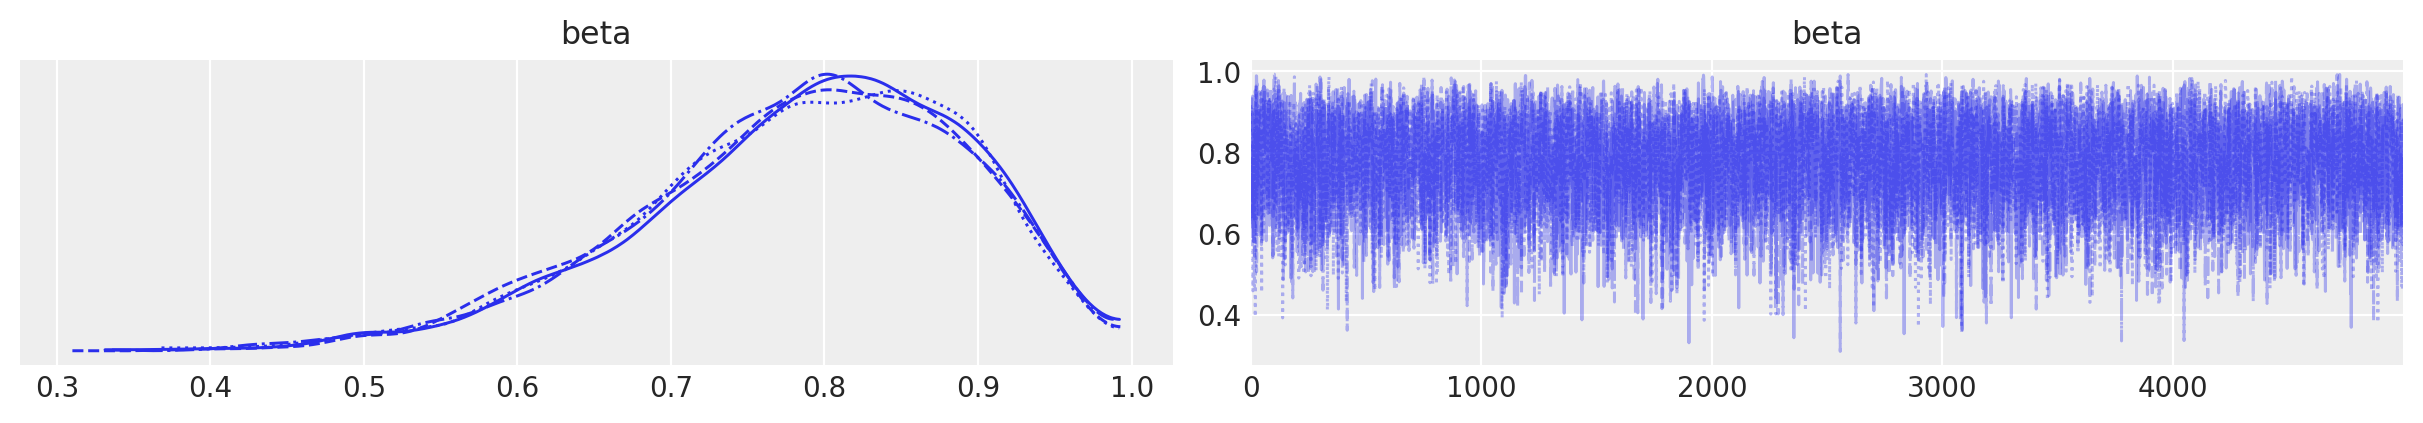

<IPython.core.display.Javascript object>

In [35]:
# Plot the posterior:
# * the left panel is a smoothed histogram (using kernel density estimation) 
#   of the marginal posteriors of each stochastic random variable (there are 4 
#   curves, one for each markov chain)
# * the right panel contains the samples of the Markov chain plotted in 
#   sequential order. In terms of MCMC, this panel represents the path followed by
#   the MCMC algorithm through the posterior sapce.

az.plot_trace(trace)

<Axes: title={'center': 'beta'}>

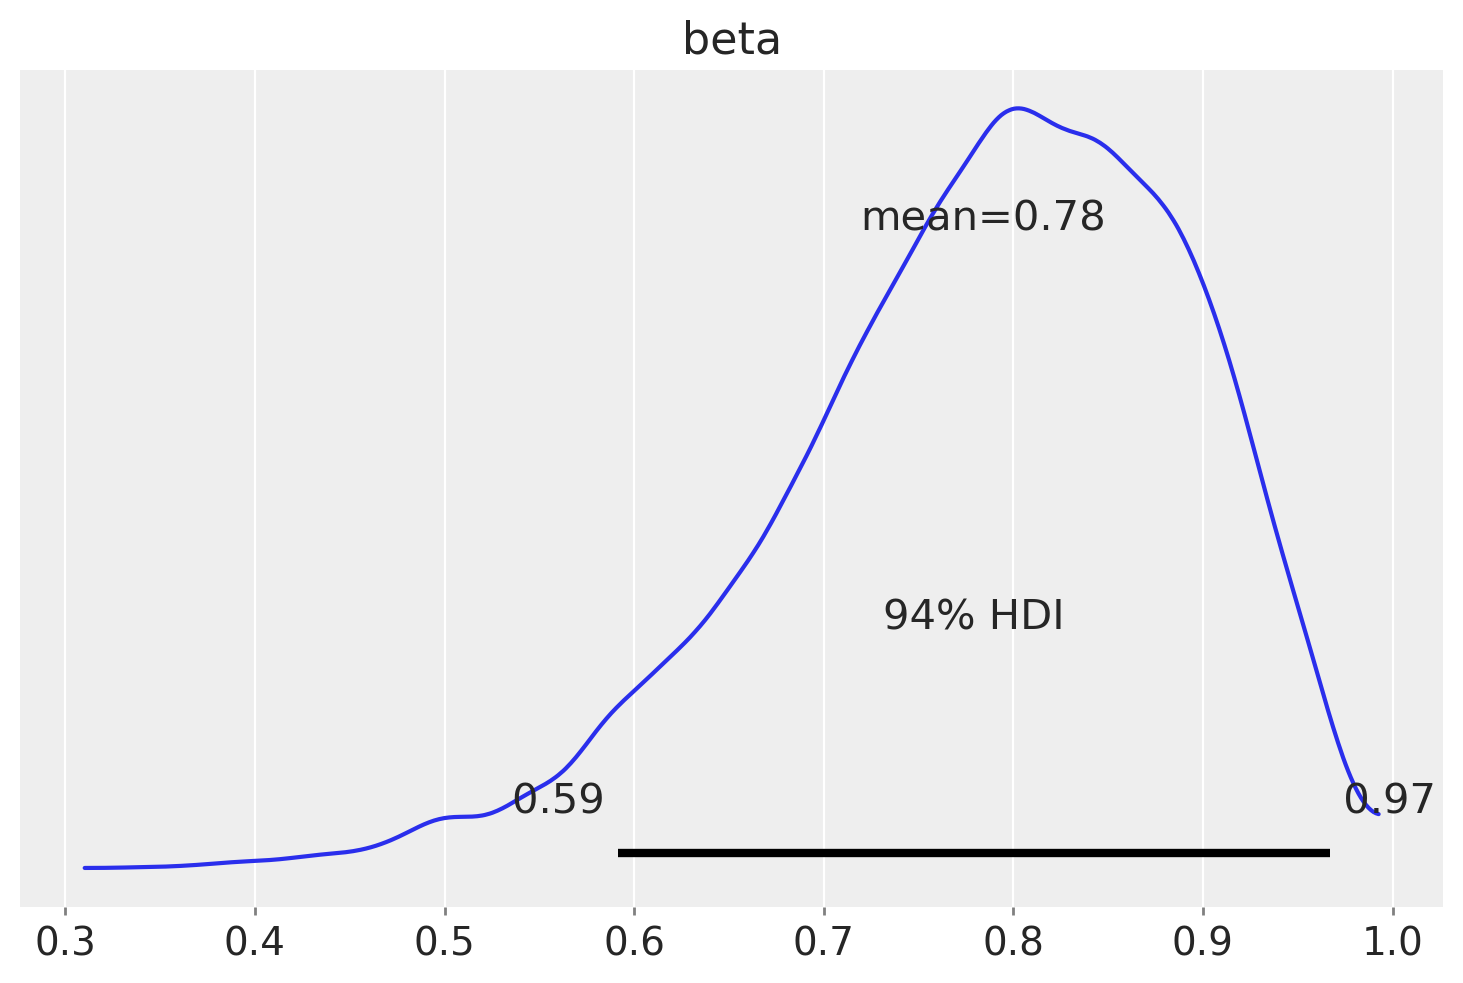

<IPython.core.display.Javascript object>

In [36]:
# Plot a smoothed version of the posterior PDF.
# The plot includes: the mean and a 94% highest density interval (HDI).

az.plot_posterior(trace)

### 6.2.2 A Gamma-Poisson example

For more practice with MCMC simulation, let us use the `pymc` tool to approximate the Gamma-Poisson posterior corresponding to the next equations, considering that we observed data $(Y_1,Y_2) = (2,8)$. 

$Y_i \mid \lambda \sim Poisson(\lambda)$ <P>
$\lambda \sim Gamma(3,1)$ <P>

Recall that this involves two steps. In step 1, we define the Gamma-Poisson model structure, specifying the aspects upon which it depends: the data (likelihood) and the parameters (priors). In step 2, we simulate the posterior. <P>

Our code will incorporate the vector $(2,8)$ of $Y$ observations in the Poisson likelihood, as opposed to a single value in previous example. The observations are passed to the Poisson function through the `observed` argument. <P>

The model includes a rate parameter $\lambda$, that follows a $Gamma(3,1)$ distribution. The likelihood of the data is modeled with a $Poisson(\lambda)$ distribution.

In [37]:
# Define the model prior and likelihood.

with pm.Model() as gamma_poisson_model:
    _lambda_ = pm.Gamma("_lambda_", 3, 1)
    y        = pm.Poisson("y", mu=_lambda_, observed=np.array([2, 8]))

    # Get 5000 samples from the model using a MCMC simulation.
    # The number of Markov chains to run in parallel is 4.
    # Run 5000 additional warm up iterations, before collecting our samples.
    
    trace   = pm.sample(5000, tune=5000, chains=4, random_seed=84735)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [_lambda_]


Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 2 seconds.


<IPython.core.display.Javascript object>

array([[<Axes: title={'center': '_lambda_'}>,
        <Axes: title={'center': '_lambda_'}>]], dtype=object)

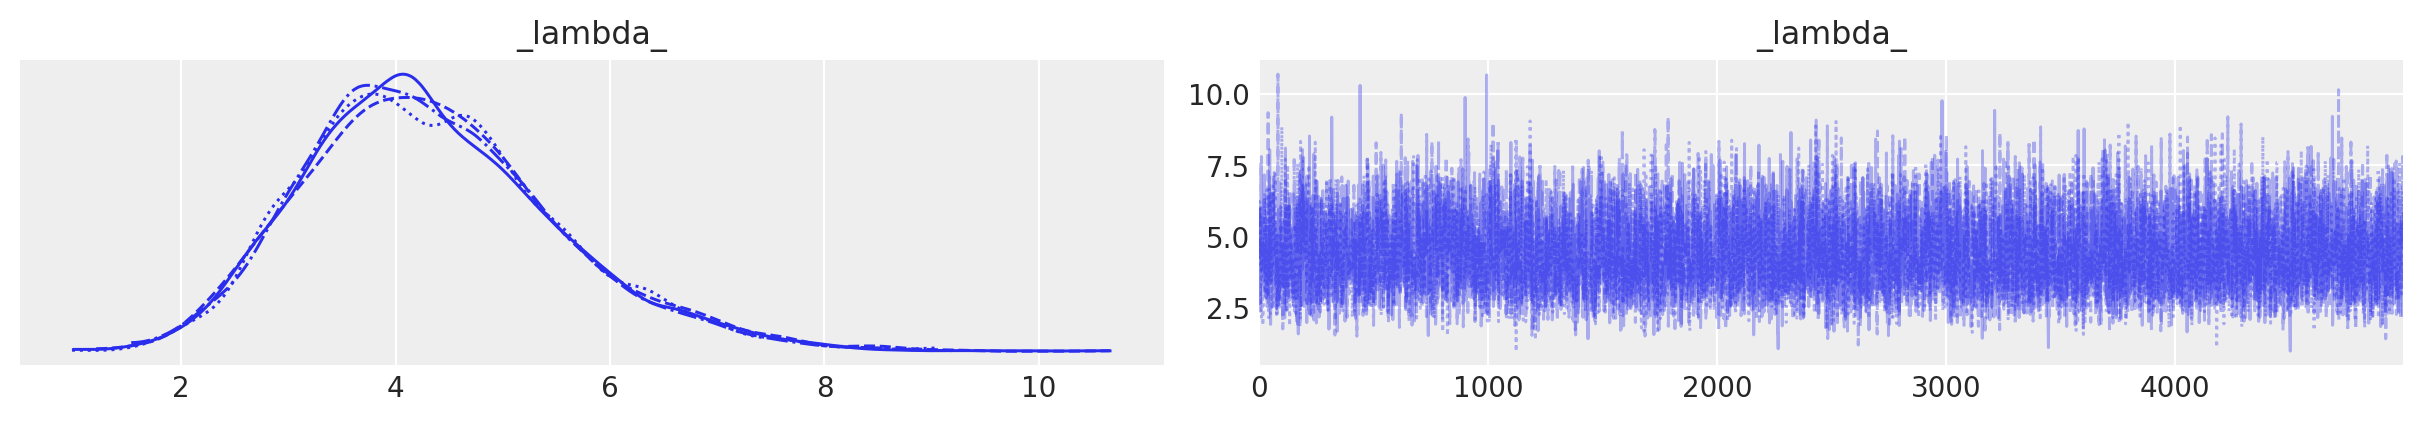

<IPython.core.display.Javascript object>

In [38]:
az.plot_trace(trace)

<Axes: title={'center': '_lambda_'}>

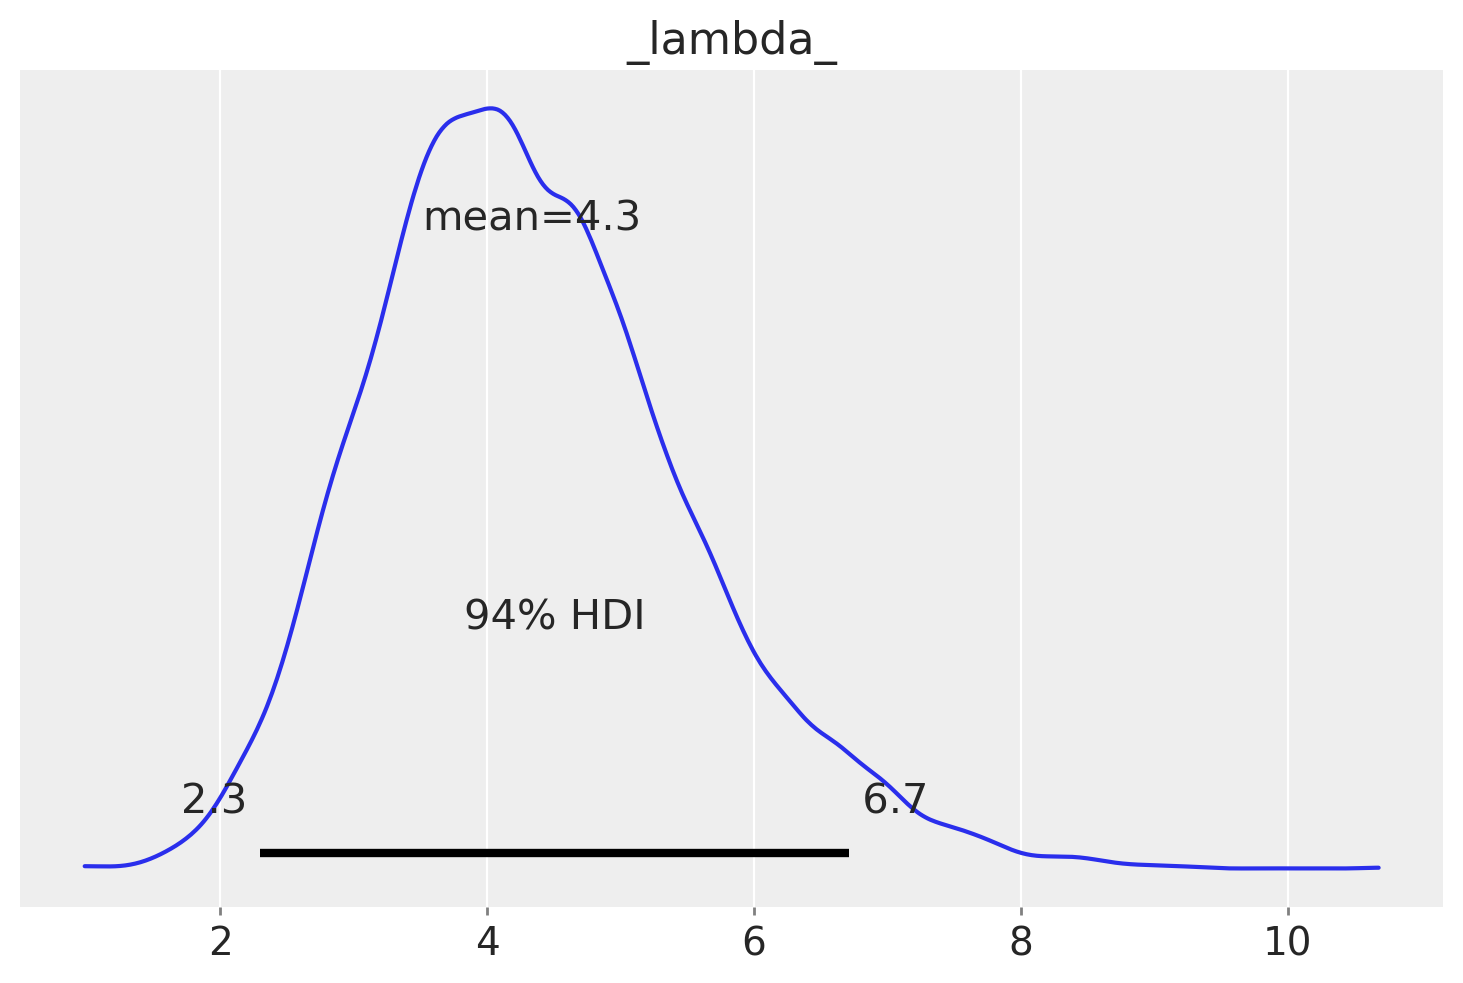

<IPython.core.display.Javascript object>

In [39]:
az.plot_posterior(trace)

In [40]:
trace.sample_stats

<xarray.Dataset>
Dimensions:                (chain: 4, draw: 5000)
Coordinates:
  * chain                  (chain) int64 0 1 2 3
  * draw                   (draw) int64 0 1 2 3 4 5 ... 4995 4996 4997 4998 4999
Data variables: (12/17)
    step_size_bar          (chain, draw) float64 1.328 1.328 ... 1.359 1.359
    diverging              (chain, draw) bool False False False ... False False
    perf_counter_start     (chain, draw) float64 1.349e+04 ... 1.35e+04
    max_energy_error       (chain, draw) float64 5.313 0.1215 ... -0.1012 0.5374
    tree_depth             (chain, draw) int64 1 1 2 2 2 2 2 2 ... 1 1 1 1 1 1 1
    step_size              (chain, draw) float64 1.495 1.495 ... 1.123 1.123
    ...                     ...
    process_time_diff      (chain, draw) float64 9.455e-05 ... 8.054e-05
    smallest_eigval        (chain, draw) float64 nan nan nan nan ... nan nan nan
    energy                 (chain, draw) float64 9.377 6.839 6.814 ... 6.05 6.87
    perf_counter_diff      (chain, draw) float64 9.458e-05 ... 8.051e-05
    n_steps                (chain, draw) float64 1.0 1.0 3.0 3.0 ... 1.0 1.0 1.0
    acceptance_rate        (chain, draw) float64 0.004925 0.8856 ... 1.0 0.5843
Attributes:
    created_at:                 2024-02-08T22:52:21.786120
    arviz_version:              0.17.0
    inference_library:          pymc
    inference_library_version:  5.10.3
    sampling_time:              1.859034776687622
    tuning_steps:               5000

<IPython.core.display.Javascript object>

In [41]:
#print(trace)
print(trace.posterior)

<xarray.Dataset>
Dimensions:   (chain: 4, draw: 5000)
Coordinates:
  * chain     (chain) int64 0 1 2 3
  * draw      (draw) int64 0 1 2 3 4 5 6 ... 4993 4994 4995 4996 4997 4998 4999
Data variables:
    _lambda_  (chain, draw) float64 5.577 5.865 3.215 ... 5.134 4.619 6.115
Attributes:
    created_at:                 2024-02-08T22:52:21.770419
    arviz_version:              0.17.0
    inference_library:          pymc
    inference_library_version:  5.10.3
    sampling_time:              1.859034776687622
    tuning_steps:               5000


<IPython.core.display.Javascript object>

In [42]:
# Save the posterior parameter 'lambda' values to a numpy array and then to a text file.

trace2_npy = trace.posterior._lambda_.to_numpy()

with open("Bayes-Rules-6-2-2-Gamma-Poisson-posterior.dat", "w") as f:
    trace2_npy.tofile(f, sep=' ', format='%.4f')

<IPython.core.display.Javascript object>

## 6.3 Markov chain diagnostics

Even when we are able to derive a Bayesian posterior, we can use posterior simulation to verify our work and provide some intuition. More importantly, when we are not able to derive a posterior, simulated samples provide a crucial approximation. In the MCMC examples above, we saw that the Markov chains traverse the sample space of our parameter ($\pi$ or $\lambda$) and, in the end, mimic a random sample that eventually converges to the posterior. "Approximation" and "converges" are key words here, since **simulations are not perfect**. This leads us to the following questions:
* What does a good Markov chain look like?
* How can we tell if our Markov chain sample produces a reasonable approximation of the posterior?
* How big should our Markov chain sample size be?

There are no one-size-fits-all magic formula that provide definitive answers here. Rather, it is through experience that you get a feel for what "good" Markov chains look like and what you can do to fix a "bad" Markov chain. In this section, we will focus on a couple visual diagnostic tools that will get us started: **trace plots** and **parallel chains**. These can be complemented with a few numerical diagnostics: **effective sample size**, **autocorrelation**, and **R-hat** ($\hat{R}$). Utilizing these diagnostics should be done holistically. Since no single visual or numerical diagnostic is one-size-fits-all, they provide a fuller picture of Markov chain quality when considered together. Other excellent diagnostics exist, but we focus here on those that are common and easy to implement in the software packages we use.

### 6.3.1 Examining trace plots

Reexamine the trace plots for the Beta-Binomial simulation Figure. 

![Trace plots of the four parallel Markov chains of pi](fig-6-08-mcmc-trace-plots.png) <P>
_Figure 6.8_

These are textbook examples of what we want trace plots to look like. Mainly, they look like a bunch of **white noise** with no discernible trends or notable phenomena. This nothingness implies that the chains are stable. In contrast, the hypothetical Markov chains for the same Beta-Binomial model shown in next Figure illustrate potential chain behavior that should give us pause.

![](fig-6-12-mcmc-trace-plots.png) <P>
_Figure 6.12_

First, consider the trace plots in left panel of previous Figure. The downward trend in Chain $A$ indicates that it has not yet stabilized after 5000 iterations. It means that our chain has not yet "found" or does not yet know how to explore the range of posterior plausible $\pi$ values. The downward trend also hints at strong correlation among the chain values: they do not look like independent noise. All of this to say that Chain $A$ is **mixing slowly**. This is bad. Though Markov chains are inherently dependent, the more they behave like fast mixing (noisy) independent samples, the smaller the error in the resulting posterior approximation (roughly speaking). Chain $B$ exhibits a different problem. As evidenced by the two completely flat lines in the trace plot, it tends to get stuck when it visits smaller values of $\pi$.

The density plots in right panel of previous Figure confirm that both of these chains result in a serious issue: they produce poor approximations of the $Beta(11,3)$ posterior (the black line), and thus misleading posterior conclusions. Consider Chain $A$. Since it is mixing so slowly, it has only explored $\pi$ values in the rough range from 0.6 to 0.9 in its first 5000 iterations. As a result, its posterior approximation overestimates the plausibility of $\pi$ values in this range while completely underestimating the plausibility of values outside this range. Next, consider Chain $B$. In getting stuck, Chain $B$ over-samples some values in the left tail of the posterior $\pi$ values. This phenomenon produces the erroneous spikes in the posterior
approximation.

In practice, we run mcmc simulations when we can not specify the posterior, and thus want to approximate it. This means that we do not have the privilege of being able to compare our simulation results to the "real" posterior. This is why diagnostics are so important. If we see bad trace plots like those in previous Figure, there are some immediate steps we can take:
1. Check the model. Are the assumed prior and data models appropriate?
2. Run the chain for more iterations. Some undesirable short-term chain trends might iron out in the long term.

We will get practice with the more nuanced Step 1. Step 2 is easy, though it requires extra computation time.


### 6.3.2 Comparing parallel chains

Recall that our `pymc` simulation for the Beta-Binomial model produced four parallel Markov chains. Not only do we want to see stability in each individual chain, as discussed above, but we want to see consistency across the
four chains. Mainly, though we expect different chains take different paths, they should exhibit similar features and produce similar posterior approximations. For example, the trace plots for the four parallel chains in Figure 6.8 appear similar in their randomness. Further, in the next Figure density plots, we observe that these four chains produce nearly indistinguishable posterior approximations. This provides evidence that our simulation is stable and sufficiently long. Meaning that if we run the chains for more iterations, likely it would not produce drastically different or improved posterior approximations.

![Figure 6.13 Density plot of the four parallel Markov chains for pi.](fig-6-13-mcmc-chains-densities-pi.png) <P>
_Figure 6.13_

For a point of comparison, let us implement a shorter Markov chain simulation for the same model. Instead of running four parallel chains for 10000 iterations and draw 5000 samples from each, run four parallel chains for only 100 iterations and a resulting sample size of 50 each.

The trace plots and corresponding density plots of the short Markov chains are shown in Figure 6.14. Though the chains' trace plots exhibit similar random behavior, their corresponding density plots differ, hence they produce discrepant posterior approximations. In the face of such instability and confusion about which of these four approximations is the most accurate, it would be a mistake to stop our simulation after only 100 iterations.

![Figure 6.14 Trace plots and density plots of the four short parallel Markov chains for pi, each of length 50.](fig-6-14-mcmc-chains-short-densities-pi.png) <P>
_Figure 6.14_


## 6.3.3 Calculating effective sample size and autocorrelation

Recall from Section 6.3.1 that the more a dependent Markov chain behaves like an independent sample, the smaller the error in the resulting posterior approximation (loosely speaking). Though trace plots provide some visual
insight into this behavior, supplementary numerical assessments can provide more nuanced information. To begin, recall that our Markov chain simulation `bb_sim` produced a combined 20000 dependent values of $\pi$, sampled from models other than the posterior. We then used this chain to approximate the posterior model of $\pi$. Knowing that the error in this approximation is likely larger than if we had used 20000 independent sample values drawn directly from the posterior rises the following question: How many independent sample values would produce an equivalently accurate posterior approximation? The effective sample size ratio provides an answer.

**Effective sample size ratio**

Let $N$ denote the actual sample size or length of a dependent Markov chain. The effective sample size of this chain, $N_{eff}$, quantifies the number of independent samples it would take to produce an equivalently accurate posterior approximation. The greater the $N_{eff}$ the better, yet it is typically true that the accuracy of a Markov chain approximation is only as good as that of a smaller independent sample.

That is, it is typically true that $N_{eff}<N$, thus the effective sample size ratio is less than 1:<P>

$\frac{Neff}{N} < 1$

There is no magic rule for interpreting this ratio, and it should be utilized alongside other diagnostics such as the trace plot. That said, we might be suspicious of a Markov chain for which the effective sample size ratio is less than 0.1, i.e., the effective sample size $N_{eff}$ is less than 10% of the actual sample size $N$.<P>

A quick call to the $neff\_ratio()$ function from the `bayesplot` package provides the estimated effective sample size ratio for our Markov chain sample of `pi` values. Here, the accuracy in using our 20000 length Markov chain to approximate the posterior of $\pi$ is roughly as great as if we had used only 34% as many independent values. Put another way, our 20000 Markov chain values are about as useful as only 6800 independent samples (0.34 x 20000). Since this ratio is above 0.1, we are not going to stress.

**Autocorrelation** provides another metric to evaluate whether our Markov chain sufficiently mimic the behavior of an independent sample. Strong autocorrelation or dependence is a bad thing: it goes hand in hand with small effective sample size ratios, and thus provides a warning sign that our resulting posterior approximations might be unreliable. We saw some evidence of this in Chain $A$ of Figure 6.12. Now, by the simple construction of a Markov chain, there is inherently going to be some autocorrelation among the chain values: one chain value ($\pi^{(i)}$) depends upon the previous chain value ($\pi^{(i-1)}$), which depends upon the one before that ($\pi^{(i-2)}$), which depends upon the one before that ($\pi^{(i-3)}$), and so on.
 
This chain of dependencies also means that each chain value depends in some degree on all previous chain values. For example, since $\pi^{(i)}$ is dependent on $\pi^{(i-1)}$, which is dependent on $\pi^{(i-2)}$, $\pi^{(i)}$ is also dependent on $\pi^{(i-2)}$. Yet this dependence, or autocorrelation, fades. It is like Tobler's first law of geography: everything is related to everything else, but near things are more related than distant things. Thus, it is typically the case that a chain value $\pi^{(i)}$ is more strongly related to the previous value ($\pi^{(i-1)}$) than to a chain value 100 steps back ($\pi^{(i-100)}$).
 
**Autocorrelation**

Lag 1 autocorrelation measures the correlation between pairs of Markov chain values that are one "step" apart (e.g., $\pi^{(i)}$ and $\pi^{(i-1)}$).

Lag 2 autocorrelation measures the correlation between pairs of Markov chain values that are two "steps" apart (e.g., $\pi^{(i)}$ and $\pi^{(i-2)}$). And so on.

Let us apply these concepts to our `bb_sim` analysis. Check out the trace plot and **autocorrelation plot** of our simulation results in Figure 6.15. For simplicity, we show the results for only one of our four parallel chains.

![A trace plot (left) and autocorrelation plot (right) for a single Markov chain from the bb_sim analysis.](fig-6-15-mcmc-trace-plots-autocorrel.png) <P>
_Figure 6.15_

Again, notice that there are no obvious patterns in the trace plot. This provides one visual clue that, though the chain values are inherently dependent, this dependence is relatively weak and limited to small lags or values that are just a few steps apart. This observation is supported by the autocorrelation plot which marks the autocorrelation (y-axis) at lags 0 through 20 (x-axis). The lag 0 autocorrelation is naturally 1, since it measures the correlation between a Markov chain value and itself. From there, the lag 1 autocorrelation is roughly 0.5, indicating moderate correlation among chain values that are only 1 step apart. But then the autocorrelation quickly drops off and is effectively 0 by lag 5. That is, there is very little correlation between Markov chain values that are more than a few steps apart. This is all good news. It is an additional confirmation that our Markov chain is **mixing quickly**, i.e., quickly moving around the range of posterior plausible $\pi$ values, and thus at least mimicking an independent sample.

Presuming you have never seen an autocorrelation plot before, we imagine that it is not very obvious that the plot in Figure 6.15 is a "good" one. For contrast, consider the results for an unhealthy Markov chain (Figure 6.16). The trace plot exhibits strong trends, and hence autocorrelation, in the Markov chain values. This observation is echoed and further formalized by the autocorrelation plot. The slow decrease in the autocorrelation curve indicates that the dependence between chain values does not quickly fade away. In fact, there is a roughly 0.9 correlation between Markov chain values that are a full 20 steps apart! Since its chain values are so strongly tied to the previous values, this chain is **slow mixing**: it would take a long time for it to adequately explore the full range of the posterior. Thus, just as with the slow mixing Chain $A$ in Figure 6.12, we should be wary about using this chain to approximate the posterior. Let us tie these ideas together.

![A trace plot (left) and autocorrelation plot (right) for a slow mixing Markov chain of pi.](fig-6-16-mcmc-trace-plots-autocorrel.png) <P>
_Figure 6.16_

**Fast vs slow mixing Markov chains**

**Fast mixing* chains exhibit a behavior similar to that of an independent sample: the chains move "quickly" around the range of posterior plausible values, the autocorrelation among the chain values drops off quickly, and the effective sample size ratio is reasonably large. **Slow mixing** chains do not enjoy the features of an independent sample: the chains move "slowly" around the range of posterior plausible values, the autocorrelation among the chain values drops off very slowly, and the effective sample size ratio is small.

So what do we do if ours is a slow mixing chain? The first possible solution is the tried and true "run a longer chain". Even a slow mixing chain can eventually produce a good posterior approximation if we run it for enough iterations. Another common approach is to **thin** the Markov chain. For example, from our original chain of 5000 $\pi$ values, we might keep every second value and toss out the rest: {$\pi^{(2)}$, $\pi^{(4)}$, $\pi^{(6)}$, ..., $\pi^{(5000)}$}. Or, we might keep every ten chain values: {$\pi^{(10)}$, $\pi^{(20)}$, $\pi^{(30)}$, ..., $\pi^{(5000)}$}. By discarding the draws in between, we remove the strong correlations at low lags. For example, $\pi^{(20)}$ is less correlated with the previous value in the thinned chain ($\pi^{(10)}$) than with the previous value in the original chain ($\pi^{(19)}$).
 
For illustration purposes, we thin out our original `bb_sim` chains to just every tenth value using the `thin` argument in `stan`. As a result, the autocorrelation drops off a bit earlier, after 1 lag instead of 5 (Figure 6.17). But, since this was already a quick mixing simulation with quickly decreasing autocorrelation and a relatively high effective sample size ratio, this minor improvement in autocorrelation is not worth the information we lost. Instead of a sample size of 5000 chain values, we now only have 500 values with which to approximate the posterior.

![A trace plot (left) and autocorrelation plot (right) for a single Markov chain from the bb_sim analysis, thinned to every tenth value.](fig-6-17-mcmc-trace-plots-autocorrel.png) <P>
_Figure 6.17_

We similarly thin our slow mixing chain down to every tenth value (Figure 6.18). The resulting chain still exhibits slow mixing trends in the trace plot, but the autocorrelation drops more quickly than the pre-thinned chain. This is good, but is it worth losing 90% of our original sample values? We are not so sure.

![A trace plot (left) and autocorrelation plot (right) for a slow mixing Markov chain of pi, thinned to every tenth value.](fig-6-18-mcmc-trace-plots-autocorrel.png) <P>
_Figure 6.18_

**Warning**

There is a careful line to walk when deciding whether or not to thin a Markov chain. The benefits of reduced autocorrelation do not necessarily outweigh the loss of precious chain values. That is, 5000 Markov chain values with stronger autocorrelation might produce a better posterior approximation than 500 chain values with weaker
autocorrelation. The effectiveness of thinning also depends in part on the algorithm used to construct the Markov chain. For example, the `rstan` and `rstanarm` packages used throughout this book employ an efficient Hamiltonian Monte Carlo algorithm. As such, in the current `stan` help file, the package authors advise against thinning unless your simulation hogs up too much memory on your machine.

### 6.3.4 Calculating R-hat

Just as effective sample size and autocorrelation provide numerical complements to the visual trace plot diagnostic in assessing the degree to which a Markov chain behaves like an independent sample, the split-$\hat{R}$ metric (or "R-hat" for short) provides a numerical complement to the visual comparison of parallel chains. Recall from Section 6.3.2 that, not only do we want each individual Markov chain in our simulation to be stable, we want there to be consistency across the parallel chains. R-hat addresses this consistency by comparing the variability in sampled $\pi$ values across all chains combined to the variability within each individual chain. Before presenting a more formal definition, check your intuition.

**Quiz**

Figure 6.19 provides simulation results for `bb_sim` (top row) along with a bad hypothetical alternative (bottom row). Based on the patterns in these plots, what do you think is a marker of a "good" Markov chain simulation?

a. The variability in $\pi$ values within any individual chain is less than the variability in $\pi$ values across all chains combined.

b. The variability in $\pi$ values within any individual chain is comparable to the variability in $\pi$ values across all chains combined.

The correct answer is b.

![Simulation results for bb_sim (top row) and a hypothetical alternative (bottom row). Included are trace plots of the four parallel chains (left), density plots for each individual chain (middle), and a density plot of the combined chains (right).](fig-6-19-mcmc-chains-densitie.png) <P>
_Figure 6.19_

To answer this quiz, let us analyze Figure 6.19. Based on what we learned in Section 6.3.2, we can see that `bb_sim` is superior to the alternative: its parallel chains exhibit similar features and produce similar posterior approximations. In particular, the variability in $\pi$ values is nearly identical within each chain (top middle plot). As a consequence, the variability in $\pi$ values across all chains combined (top right plot) is similar to that of the individual chains. In contrast, notice that the four parallel chains in the alternative simulation produce conflicting posterior approximations (bottom middle plot), and hence an unstable and poor posterior approximation when we combine these chains (bottom right plot). As a consequence, the range and variability in $\pi$ values across all chains combined are much larger than the range and variability in $\pi$ values within any individual chain.

Bringing this analysis together, we have intuited the importance of the relationship between the variability in values across all chains combined and within the individual parallel chains. Specifically:

* in a "good" Markov chain simulation, the variability across all parallel chains combined will be roughly comparable to the variability within any individual chain.

* in a "bad" Markov chain simulation, the variability across all parallel chains combined might exceed the typical variability within each chain.

We can quantify the relationship between the combined chain variability and within-chain variability using R-hat. We provide an intuitive definition of R-hat here.

**R-hat**

Consider a Markov chain simulation of parameter $\theta$ which utilizes four parallel chains. Let $Var_{combined}$ denote the variability in $\theta$ across all four chains combined and $Var_{within}$ denote the typical variability within any individual chain. The R-hat metric calculates the ratio between these two sources of variability:

$\text{R-hat}=\sqrt{\frac{Var_{combined}}{Var_{within}}}$

Ideally, R-hat $\approx$ 1, reflecting stability across the parallel chains. In contrast, R-hat > 1 indicates instability, with the variability in the combined chains exceeding that within the chains. Though no golden
rule exists, an R-hat ratio greater than 1.05 raises some red flags about the stability of the simulation.

To calculate the R-hat ratio for our simulation, we can apply the `rhat`function from the `bayesplot` package. Reflecting our observation that the variability across and within our four parallel chains is comparable, `bb_sim` has an R-hat value that is effectively equal to 1. In contrast, the bad hypothetical simulation exhibited in Figure 6.19 has an R-hat value of 5.35. That is, the variance across all chain values combined is more than 5 times the typical variance within each chain. This well exceeds the 1.05 red flag marker, providing ample evidence that the hypothetical parallel chains do not produce consistent posterior approximations, thus the simulation is unstable.

array([<Axes: title={'center': '_lambda_\n0'}>,
       <Axes: title={'center': '_lambda_\n1'}>,
       <Axes: title={'center': '_lambda_\n2'}>,
       <Axes: title={'center': '_lambda_\n3'}>], dtype=object)

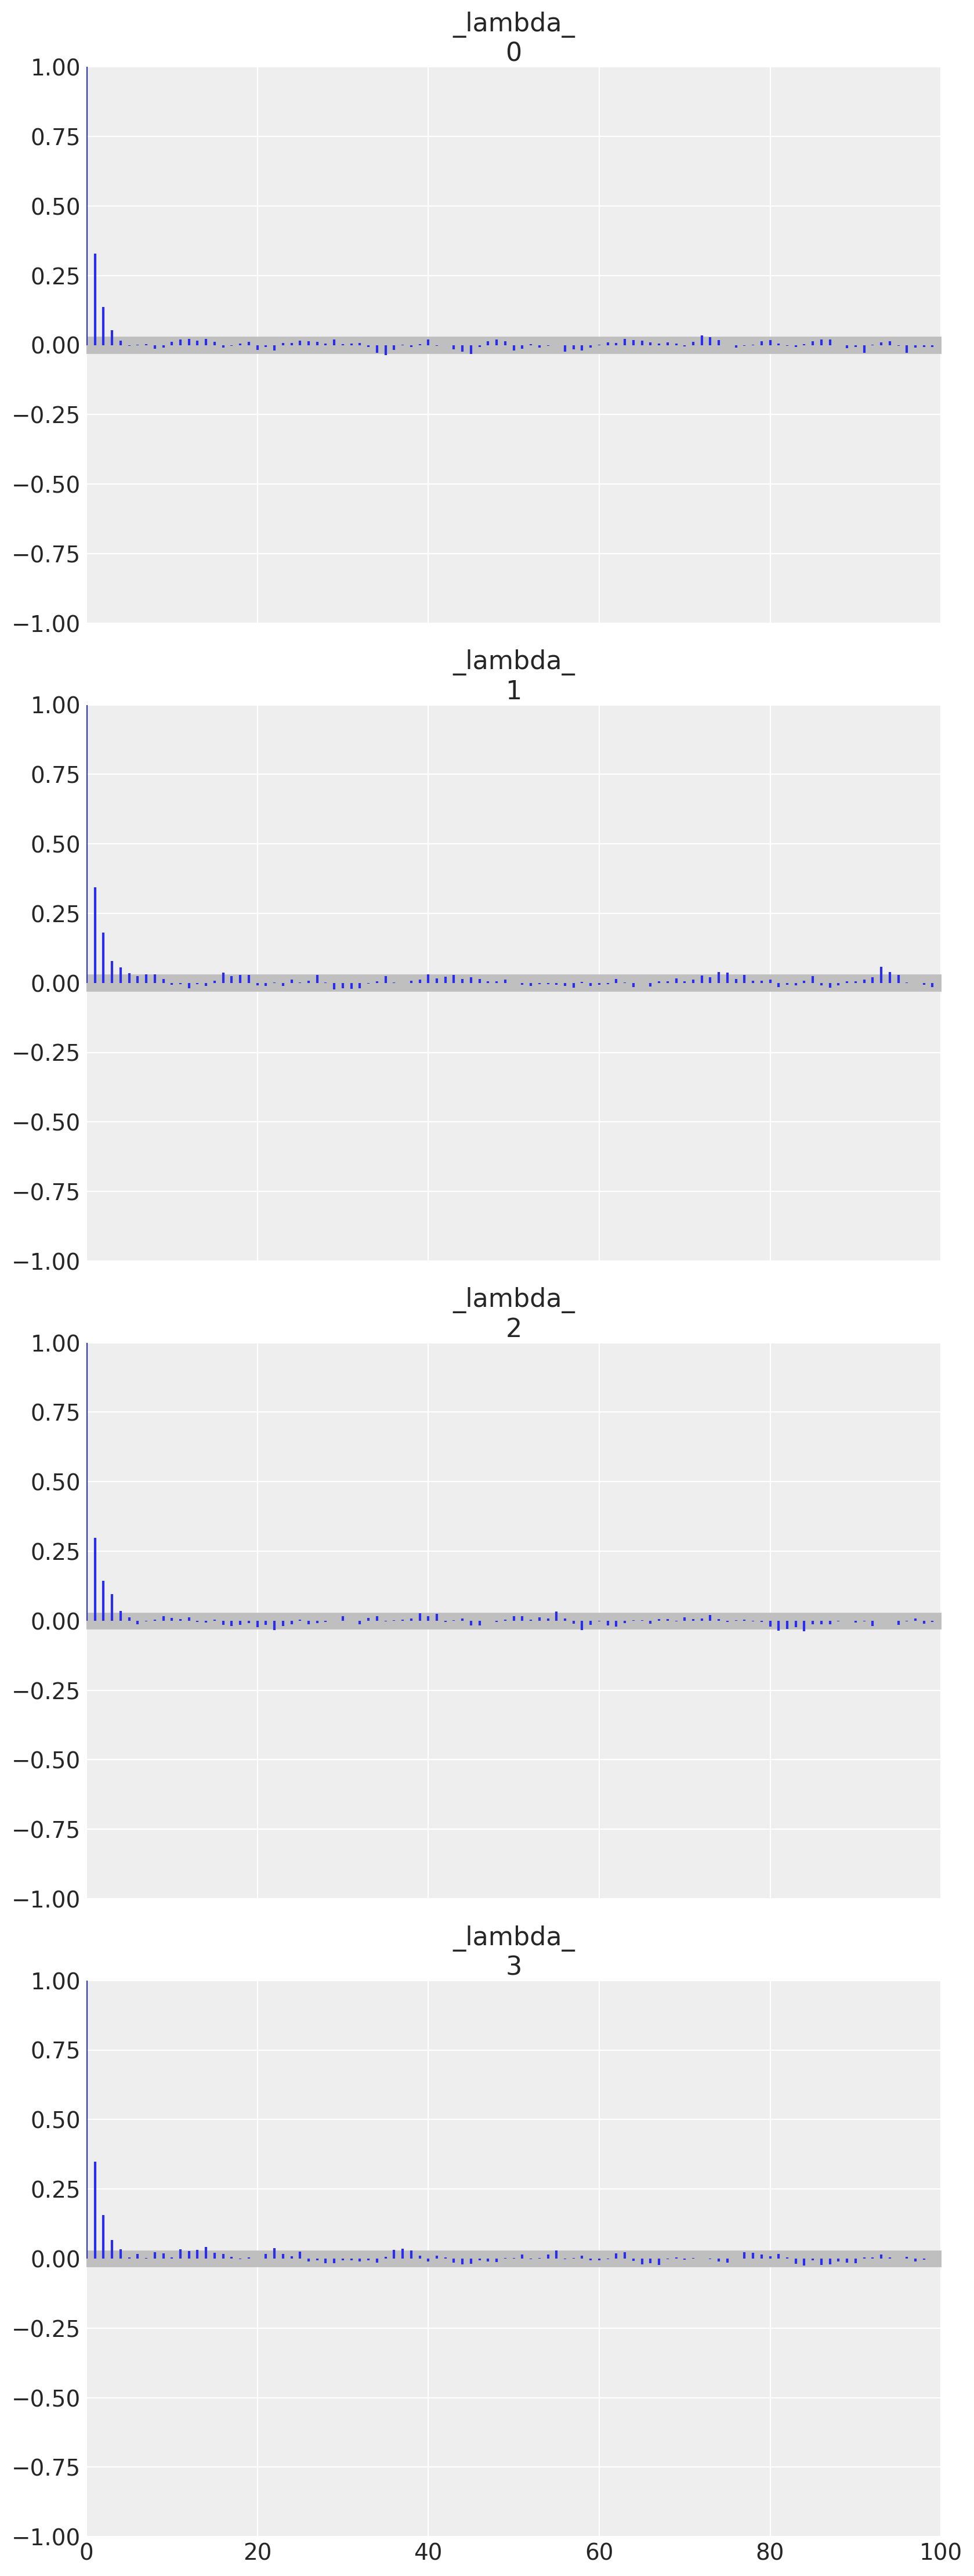

<IPython.core.display.Javascript object>

In [48]:
# Plot the autocorrelation function (ACF) for all the 4 mcmc chains of the parameter 'lambda' values
az.plot_autocorr(trace, grid=(4, 1))

In [44]:
pm.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
_lambda_,4.333,1.187,2.299,6.708,0.013,0.009,8021.0,12010.0,1.0


<IPython.core.display.Javascript object>

In [45]:
watermark

Last updated: 2024-02-08T22:52:26.205126+00:00

Python implementation: CPython
Python version       : 3.11.7
IPython version      : 8.21.0

Compiler    : GCC 12.3.0
OS          : Linux
Release     : 6.5.0-15-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 20
Architecture: 64bit



<IPython.core.display.Javascript object>